In [7]:
%pip install pandas matplotlib seaborn scikit-learn

In [8]:
# ── CELL 1 — Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('dark_background')
sns.set_palette("husl")
print("Libraries loaded ✅")

Libraries loaded ✅


In [9]:
# from google.colab import drive
# drive.mount('/content/drive')

In [10]:
# ── CELL 2 — Load Yelp Dataset ──

# Load as a standard JSON array (removed lines=True)
df = pd.read_json('/content/drive/MyDrive/yelp_80000_fixed.json')

# Slices the first 80,000 rows since nrows is not supported without lines=True
df = df.head(84)

# Keep only what we need
df = df[['text', 'stars', 'date', 'useful', 'funny', 'cool']]
df['date'] = pd.to_datetime(df['date'])

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (83, 6)
Columns: ['text', 'stars', 'date', 'useful', 'funny', 'cool']


,text,stars,date,useful,funny,cool
0,Batteries died within a year ...: I bought thi...,2,2022-07-07,4,4,6
1,"works fine, but Maha Energy is better: Check o...",4,2021-01-29,6,27,17
2,Great for the non-audiophile: Reviewed quite a...,4,2020-10-30,49,19,16
3,DVD Player crapped out after one year: I also ...,1,2021-02-01,46,18,20
4,"Incorrect Disc: I love the style of this, but ...",2,2021-02-03,20,10,14


In [11]:
# ── CELL 3 — Basic Stats ──
print("=== BASIC STATISTICS ===")
print(df.describe())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nStar distribution:\n{df['stars'].value_counts().sort_index()}")

=== BASIC STATISTICS ===
           stars                           date     useful      funny  \
count  83.000000                             83  83.000000  83.000000   
mean    3.108434  2021-07-06 08:05:46.987951872  23.602410  16.927711   
min     1.000000            2020-01-09 00:00:00   0.000000   0.000000   
25%     1.500000            2020-12-16 12:00:00   7.000000   9.000000   
50%     4.000000            2021-06-01 00:00:00  27.000000  18.000000   
75%     5.000000            2022-02-19 00:00:00  38.500000  24.500000   
max     5.000000            2022-12-30 00:00:00  50.000000  30.000000   
std     1.615565                            NaN  16.287014   9.299598   

            cool  
count  83.000000  
mean    9.674699  
min     0.000000  
25%     4.000000  
50%     9.000000  
75%    15.500000  
max    20.000000  
std     6.168584  

Missing values:
text      0
stars     0
date      0
useful    0
funny     0
cool      0
dtype: int64

Star distribution:
stars
1    21
2    17
4 

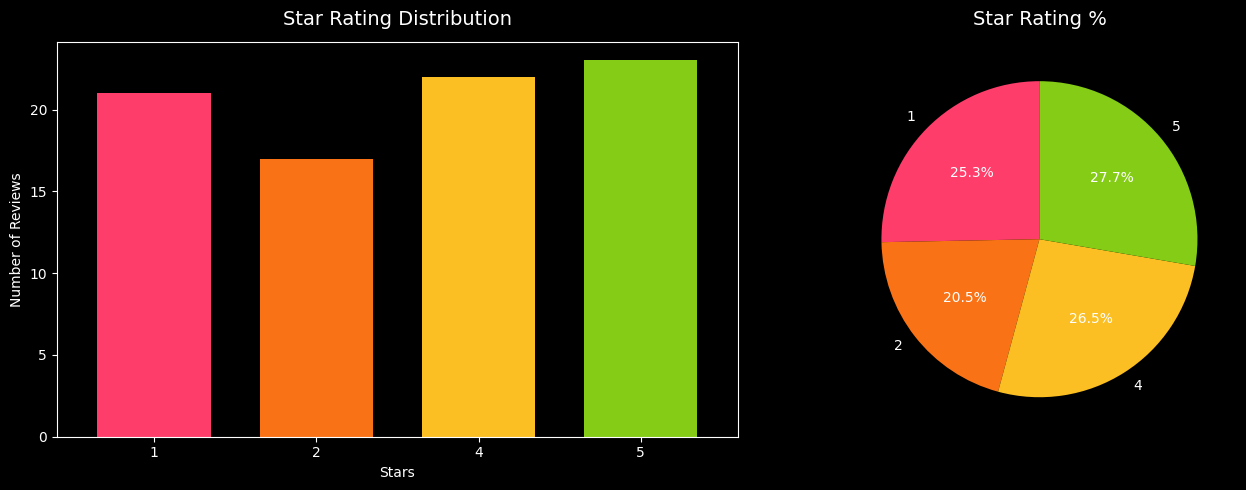

1-star reviews: 21 (25.3%)
2-star reviews: 17 (20.5%)
3-star reviews: 0 (0.0%)
4-star reviews: 22 (26.5%)
5-star reviews: 23 (27.7%)


In [12]:
# ── CELL 4 — Star Rating Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df['stars'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#ff3d6b','#f97316','#fbbf24','#84cc16','#22c55e'],
    edgecolor='none', width=0.7
)
axes[0].set_title('Star Rating Distribution', fontsize=14, pad=12)
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['stars'].value_counts().sort_index().plot(
    kind='pie', ax=axes[1],
    colors=['#ff3d6b','#f97316','#fbbf24','#84cc16','#22c55e'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Star Rating %', fontsize=14, pad=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/star_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"1-star reviews: {(df['stars']==1).sum():,} ({(df['stars']==1).mean()*100:.1f}%)")
print(f"2-star reviews: {(df['stars']==2).sum():,} ({(df['stars']==2).mean()*100:.1f}%)")
print(f"3-star reviews: {(df['stars']==3).sum():,} ({(df['stars']==3).mean()*100:.1f}%)")
print(f"4-star reviews: {(df['stars']==4).sum():,} ({(df['stars']==4).mean()*100:.1f}%)")
print(f"5-star reviews: {(df['stars']==5).sum():,} ({(df['stars']==5).mean()*100:.1f}%)")

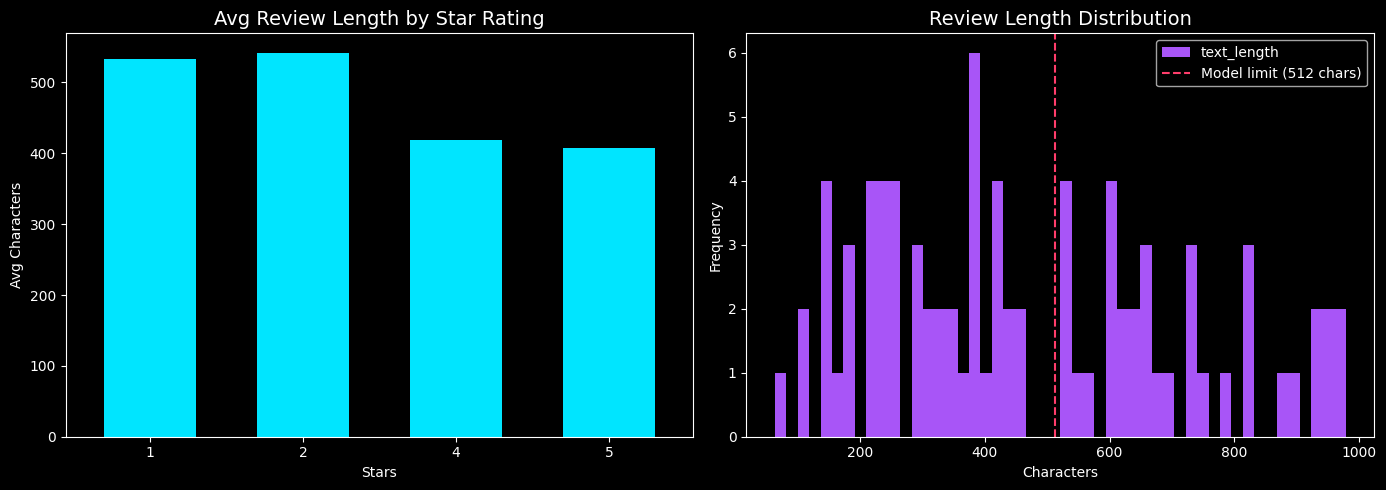

Avg review length: 470 chars
Reviews > 512 chars (will be truncated): 35 (42.2%)


In [13]:
# ── CELL 5 — Review Length Analysis ──
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length by star rating
df.groupby('stars')['text_length'].mean().plot(
    kind='bar', ax=axes[0], color='#00e5ff', edgecolor='none', width=0.6
)
axes[0].set_title('Avg Review Length by Star Rating', fontsize=14)
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Avg Characters')
axes[0].tick_params(axis='x', rotation=0)

# Distribution of lengths
df['text_length'].clip(upper=2000).plot(
    kind='hist', ax=axes[1], bins=50, color='#a855f7', edgecolor='none'
)
axes[1].set_title('Review Length Distribution', fontsize=14)
axes[1].set_xlabel('Characters')
axes[1].axvline(512, color='#ff3d6b', linestyle='--', label='Model limit (512 chars)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg review length: {df['text_length'].mean():.0f} chars")
print(f"Reviews > 512 chars (will be truncated): {(df['text_length']>512).sum():,} ({(df['text_length']>512).mean()*100:.1f}%)")

In [14]:
df.describe()

,stars,date,useful,funny,cool,text_length,word_count
count,83.000000,83,83.000000,83.000000,83.000000,83.000000,83.000000
mean,3.108434,2021-07-06 08:05:46.987951872,23.602410,16.927711,9.674699,470.072289,86.253012
min,1.000000,2020-01-09 00:00:00,0.000000,0.000000,0.000000,64.000000,11.000000
25%,1.500000,2020-12-16 12:00:00,7.000000,9.000000,4.000000,252.000000,46.000000
50%,4.000000,2021-06-01 00:00:00,27.000000,18.000000,9.000000,425.000000,80.000000
75%,5.000000,2022-02-19 00:00:00,38.500000,24.500000,15.500000,651.500000,117.000000
max,5.000000,2022-12-30 00:00:00,50.000000,30.000000,20.000000,978.000000,191.000000
std,1.615565,NaN,16.287014,9.299598,6.168584,248.850910,45.427467


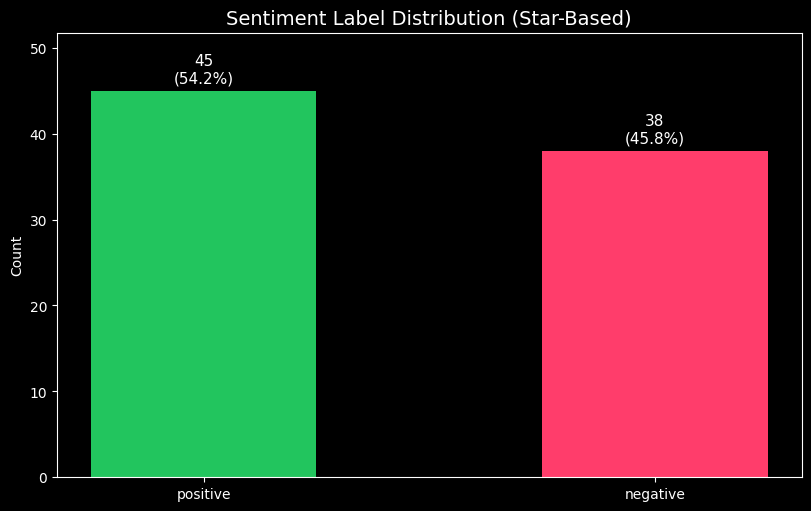

In [15]:
# ── CELL 6 — Sentiment Labels (map stars to labels) ──
def star_to_sentiment(stars):
    if stars <= 2: return 'negative'
    if stars == 3: return 'neutral'
    return 'positive'

df['sentiment_label'] = df['stars'].apply(star_to_sentiment)

# constrained_layout=True lagane se warning nahi aayegi
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
counts = df['sentiment_label'].value_counts()
colors = {'negative': '#ff3d6b', 'neutral': '#94a3b8', 'positive': '#22c55e'}
bars = ax.bar(counts.index, counts.values,
              color=[colors[l] for l in counts.index], edgecolor='none', width=0.5)

# Y-axis ki limit ko thoda barha diya taake upar text ke liye jagah ban jaye
ax.set_ylim(0, max(counts.values) * 1.15)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(counts.values) * 0.02),
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=11)

ax.set_title('Sentiment Label Distribution (Star-Based)', fontsize=14)
ax.set_ylabel('Count')

plt.savefig('/content/drive/MyDrive/sentiment_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
df.describe()

,stars,date,useful,funny,cool,text_length,word_count
count,83.000000,83,83.000000,83.000000,83.000000,83.000000,83.000000
mean,3.108434,2021-07-06 08:05:46.987951872,23.602410,16.927711,9.674699,470.072289,86.253012
min,1.000000,2020-01-09 00:00:00,0.000000,0.000000,0.000000,64.000000,11.000000
25%,1.500000,2020-12-16 12:00:00,7.000000,9.000000,4.000000,252.000000,46.000000
50%,4.000000,2021-06-01 00:00:00,27.000000,18.000000,9.000000,425.000000,80.000000
75%,5.000000,2022-02-19 00:00:00,38.500000,24.500000,15.500000,651.500000,117.000000
max,5.000000,2022-12-30 00:00:00,50.000000,30.000000,20.000000,978.000000,191.000000
std,1.615565,NaN,16.287014,9.299598,6.168584,248.850910,45.427467


In [17]:
df['sentiment_label']

,sentiment_label
0,negative
1,positive
2,positive
3,negative
4,negative
...,...
78,positive
79,positive
80,positive
81,negative


/tmp/ipykernel_12532/90024312.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_time = df.set_index('date').resample('M')['stars'].agg(['count','mean'])


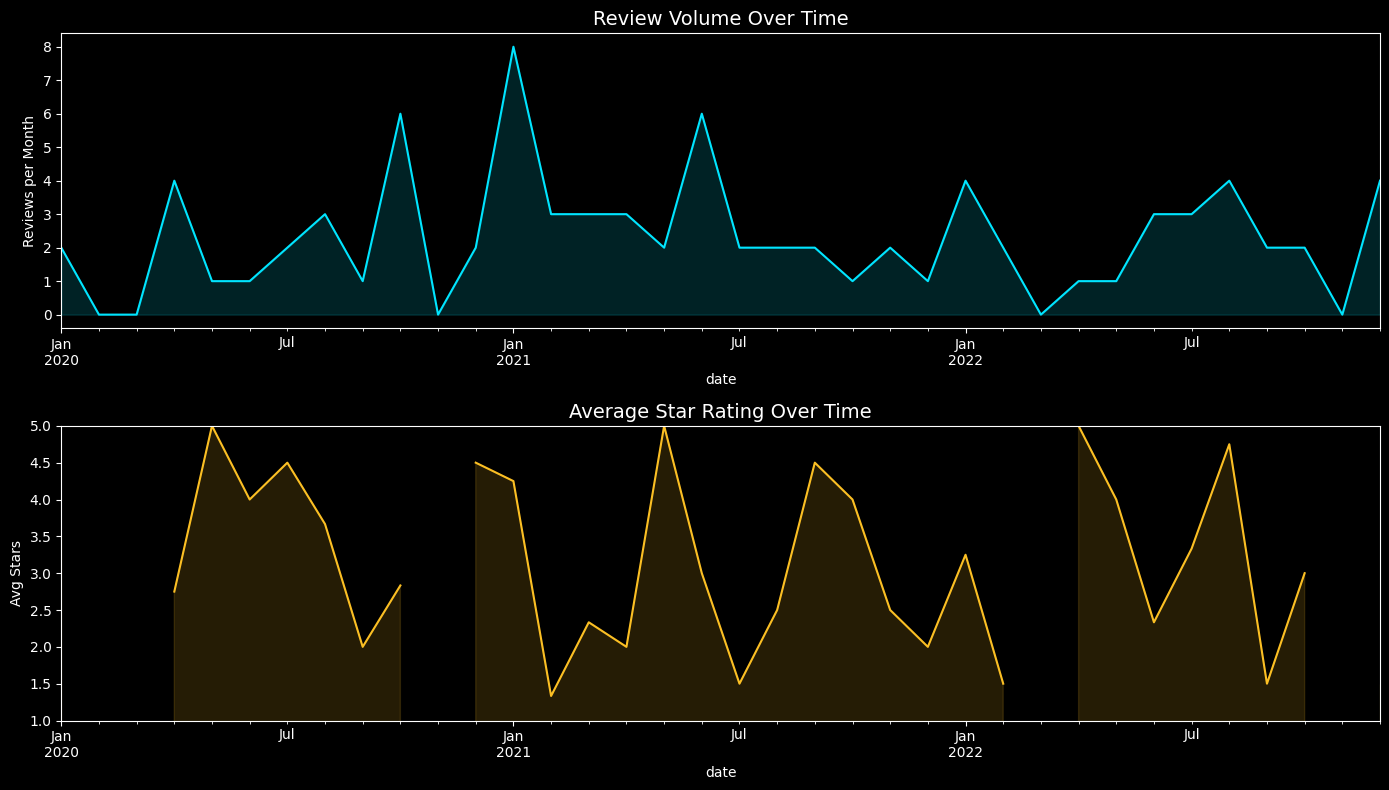

In [18]:
# ── CELL 7 — Reviews Over Time ──
df_time = df.set_index('date').resample('M')['stars'].agg(['count','mean'])
df_time.columns = ['review_count', 'avg_stars']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_time['review_count'].plot(ax=axes[0], color='#00e5ff', linewidth=1.5)
axes[0].set_title('Review Volume Over Time', fontsize=14)
axes[0].set_ylabel('Reviews per Month')
axes[0].fill_between(df_time.index, df_time['review_count'], alpha=0.15, color='#00e5ff')

df_time['avg_stars'].plot(ax=axes[1], color='#fbbf24', linewidth=1.5)
axes[1].set_title('Average Star Rating Over Time', fontsize=14)
axes[1].set_ylabel('Avg Stars')
axes[1].set_ylim(1, 5)
axes[1].fill_between(df_time.index, df_time['avg_stars'], alpha=0.15, color='#fbbf24')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── CELL 8 — Competitor Keyword Analysis ──
COMPETITORS = ["mcdonald", "subway", "kfc", "burger king",
               "starbucks", "dominos", "pizza hut"]

for kw in COMPETITORS:
    count = df['text'].str.lower().str.contains(kw).sum()
    pct = count / len(df) * 100
    avg_stars = df[df['text'].str.lower().str.contains(kw)]['stars'].mean()
    print(f"{kw:15} → {count:5,} reviews ({pct:.2f}%) | avg stars: {avg_stars:.2f}")

mcdonald        →     0 reviews (0.00%) | avg stars: nan
subway          →     0 reviews (0.00%) | avg stars: nan
kfc             →     0 reviews (0.00%) | avg stars: nan
burger king     →     0 reviews (0.00%) | avg stars: nan
starbucks       →     0 reviews (0.00%) | avg stars: nan
dominos         →     0 reviews (0.00%) | avg stars: nan
pizza hut       →     0 reviews (0.00%) | avg stars: nan


In [20]:
# ── CELL 9 — Key Insights Summary ──
print("=" * 50)
print("KEY FINDINGS FROM EDA:")
print("=" * 50)
print(f"Dataset size:        {len(df):,} reviews")
print(f"Negative reviews:    {(df['sentiment_label']=='negative').sum():,} ({(df['sentiment_label']=='negative').mean()*100:.1f}%)")
print(f"Positive reviews:    {(df['sentiment_label']=='positive').sum():,} ({(df['sentiment_label']=='positive').mean()*100:.1f}%)")
print(f"Avg review length:   {df['text_length'].mean():.0f} chars")
print(f"Need truncation:     {(df['text_length']>512).mean()*100:.1f}% of reviews")
print(f"Overall avg rating:  {df['stars'].mean():.2f} / 5.0")

KEY FINDINGS FROM EDA:
Dataset size:        83 reviews
Negative reviews:    38 (45.8%)
Positive reviews:    45 (54.2%)
Avg review length:   470 chars
Need truncation:     42.2% of reviews
Overall avg rating:  3.11 / 5.0
